# 11 — Blend v2 (Full 9-Model Ensemble)

Combines all nine model OOFs (Linear Regression, Random Forest, Gradient Boosting, XGBoost v1, MLP, XGBoost v2, XGBoost v3, LightGBM, CatBoost) and re-runs SLSQP weight optimisation.

Outputs:
- `outputs/test_local_pred_blend_v2.npy`
- `outputs/blend_v2_weights.json`

In [1]:
import os
os.environ['PYTHONWARNINGS'] = 'ignore'  # also silences warnings from n_jobs=-1 joblib subprocesses

import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

OUT_DIR = Path('../outputs')
DATA_DIR = Path('../data')

In [2]:
# Load development set target (train_local) and local test target
train_local = pd.read_parquet(OUT_DIR / 'train_local.parquet')
test_local  = pd.read_parquet(OUT_DIR / 'test_local.parquet')
y = train_local['blocked_days_Q1_2026'].astype(float).values
y_test = test_local['blocked_days_Q1_2026'].astype(float).values
print(f"Dev set y shape: {y.shape} | Local Test y shape: {y_test.shape}")

oof_files = {
    'LinearRegression': 'oof_LinearRegression.npy',
    'RandomForest':     'oof_RandomForest.npy',
    'GradientBoosting': 'oof_GradientBoosting.npy',
    'XGBoost':          'oof_XGBoost.npy',
    'XGBoost v2':       'oof_XGBoostV2.npy',
    'XGBoost v3':       'oof_XGBoostV3.npy',
    'MLP':              'oof_MLP.npy',
    'LightGBM':         'oof_LightGBM.npy',
    'CatBoost':         'oof_CatBoost.npy',
}
local_test_files = {
    'LinearRegression': 'test_local_pred_LinearRegression.npy',
    'RandomForest':     'test_local_pred_RandomForest.npy',
    'GradientBoosting': 'test_local_pred_GradientBoosting.npy',
    'XGBoost':          'test_local_pred_XGBoost.npy',
    'XGBoost v2':       'test_local_pred_XGBoostV2.npy',
    'XGBoost v3':       'test_local_pred_XGBoostV3.npy',
    'MLP':              'test_local_pred_mlp.npy',
    'LightGBM':         'test_local_pred_LightGBM.npy',
    'CatBoost':         'test_local_pred_CatBoost.npy',
}
oofs, local_test_preds = {}, {}
dev_scores, test_scores = {}, {}
for name, oof_name in oof_files.items():
    p_oof = OUT_DIR / oof_name
    p_lt  = OUT_DIR / local_test_files[name]
    if p_oof.exists():
        oof_loaded = np.load(p_oof)
        if oof_loaded.shape[0] != y.shape[0]:
            print(f'{name:<18s} | SHAPE MISMATCH: {y.shape[0]} vs {oof_loaded.shape[0]} (skip)')
            continue
        oofs[name] = np.clip(oof_loaded, 0, 90)
        mse = mean_squared_error(y, oofs[name])
        mae = mean_absolute_error(y, oofs[name])
        r2  = r2_score(y, oofs[name])
        dev_scores[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}
        print(f'{name:<18s} | OOF  MSE = {mse:8.3f}  MAE = {mae:7.3f}  R2 = {r2:.3f}')
    else:
        print(f'{name:<18s} | OOF MISSING ({oof_name})')
    if p_lt.exists():
        local_test_preds[name] = np.load(p_lt)
        pred = np.clip(local_test_preds[name], 0, 90)
        mse_t = mean_squared_error(y_test, pred)
        mae_t = mean_absolute_error(y_test, pred)
        r2_t  = r2_score(y_test, pred)
        test_scores[name] = {'MSE': mse_t, 'MAE': mae_t, 'R2': r2_t}
        print(f'{"":<18s} | Test MSE = {mse_t:8.3f}  MAE = {mae_t:7.3f}  R2 = {r2_t:.3f}')
    else:
        print(f'{name:<18s} | LOCAL TEST PRED MISSING')

model_names = [m for m in oofs.keys() if m in local_test_preds]
print('\nModels in blend:', model_names)

Dev set y shape: (29008,) | Local Test y shape: (7253,)
LinearRegression   | OOF  MSE =  357.592  MAE =  12.237  R2 = 0.432
                   | Test MSE =  356.224  MAE =  12.007  R2 = 0.426
RandomForest       | OOF  MSE =  302.791  MAE =  10.321  R2 = 0.519
                   | Test MSE =  298.109  MAE =  10.077  R2 = 0.520
GradientBoosting   | OOF  MSE =  435.791  MAE =  11.043  R2 = 0.308
                   | Test MSE =  427.872  MAE =  10.817  R2 = 0.311
XGBoost            | OOF  MSE =  294.319  MAE =  10.120  R2 = 0.533
                   | Test MSE =  289.193  MAE =   9.873  R2 = 0.534
XGBoost v2         | OOF  MSE =  296.943  MAE =  10.213  R2 = 0.529
                   | Test MSE =  291.686  MAE =   9.992  R2 = 0.530
XGBoost v3         | OOF  MSE =  295.796  MAE =  10.177  R2 = 0.531
                   | Test MSE =  291.972  MAE =   9.988  R2 = 0.530
MLP                | OOF  MSE =  382.495  MAE =  10.401  R2 = 0.393
                   | Test MSE =  377.314  MAE =  10.232  R2 

In [3]:
oof_mat = np.column_stack([oofs[m] for m in model_names])
print('oof_mat:', oof_mat.shape)

# Equal-weight baseline
blend_eq = np.clip(oof_mat.mean(axis=1), 0, 90)
mse_eq = mean_squared_error(y, blend_eq)
mae_eq = mean_absolute_error(y, blend_eq)
r2_eq  = r2_score(y, blend_eq)
dev_scores['Equal-Blend'] = {'MSE': mse_eq, 'MAE': mae_eq, 'R2': r2_eq}
print(f'Equal-weight blend OOF MSE = {mse_eq:.3f}  MAE = {mae_eq:.3f}  R2 = {r2_eq:.3f}')

oof_mat: (29008, 9)
Equal-weight blend OOF MSE = 300.347  MAE = 10.226  R2 = 0.523


In [4]:
def blend_mse(w, M, y):
    return float(mean_squared_error(y, np.clip(M @ w, 0, 90)))

k = oof_mat.shape[1]
w0 = np.full(k, 1.0 / k)
res = minimize(blend_mse, w0, args=(oof_mat, y),
               method='SLSQP', bounds=[(0.0, 1.0)] * k,
               constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}],
               options={'maxiter': 500, 'ftol': 1e-9})
w = res.x; w[w < 1e-4] = 0.0; w = w / w.sum()
print('Optimal weights:')
for m, wi in zip(model_names, w):
    print(f'  {m:<18s} = {wi:.4f}')

pred_opt = np.clip(oof_mat @ w, 0, 90)
mse_opt = mean_squared_error(y, pred_opt)
mae_opt = mean_absolute_error(y, pred_opt)
r2_opt  = r2_score(y, pred_opt)
dev_scores['Optimal-Blend'] = {'MSE': mse_opt, 'MAE': mae_opt, 'R2': r2_opt}
print(f'\nOptimal blend OOF MSE = {mse_opt:.3f}  MAE = {mae_opt:.3f}  R2 = {r2_opt:.3f}')

with open(OUT_DIR / 'blend_v2_weights.json', 'w') as f:
    json.dump({m: float(wi) for m, wi in zip(model_names, w)}, f, indent=2)

Optimal weights:
  LinearRegression   = 0.0000
  RandomForest       = 0.1297
  GradientBoosting   = 0.0000
  XGBoost            = 0.4556
  XGBoost v2         = 0.0252
  XGBoost v3         = 0.1331
  MLP                = 0.0464
  LightGBM           = 0.2101
  CatBoost           = 0.0000

Optimal blend OOF MSE = 291.637  MAE = 10.071  R2 = 0.537


In [5]:
# Build local test blend prediction
test_mat = np.column_stack([local_test_preds[m] for m in model_names])
final_lt = np.clip(test_mat @ w, 0, 90)
test_mse_blend_v2 = mean_squared_error(y_test, final_lt)
test_mae_blend_v2 = mean_absolute_error(y_test, final_lt)
test_r2_blend_v2  = r2_score(y_test, final_lt)
test_scores['Optimal-Blend'] = {'MSE': test_mse_blend_v2, 'MAE': test_mae_blend_v2, 'R2': test_r2_blend_v2}
print(f'Blend v2 Local Test MSE = {test_mse_blend_v2:.3f}  MAE = {test_mae_blend_v2:.3f}  R2 = {test_r2_blend_v2:.3f}')
np.save(OUT_DIR / 'test_local_pred_blend_v2.npy', final_lt)
print(f'Saved test_local_pred_blend_v2.npy | mean={final_lt.mean():.2f}')

Blend v2 Local Test MSE = 288.649  MAE = 9.874  R2 = 0.535
Saved test_local_pred_blend_v2.npy | mean=15.66


=== Dev (5-Fold OOF) metrics ===
                      MSE     MAE     R2
model                                   
Optimal-Blend     291.637  10.071  0.537
XGBoost           294.319  10.120  0.533
XGBoost v3        295.796  10.177  0.531
LightGBM          296.494  10.205  0.529
XGBoost v2        296.943  10.213  0.529
Equal-Blend       300.347  10.226  0.523
CatBoost          301.356  10.417  0.522
RandomForest      302.791  10.321  0.519
LinearRegression  357.592  12.237  0.432
MLP               382.495  10.401  0.393
GradientBoosting  435.791  11.043  0.308

=== Local Test metrics ===
                      MSE     MAE     R2
model                                   
Optimal-Blend     288.649   9.874  0.535
XGBoost           289.193   9.873  0.534
XGBoost v2        291.686   9.992  0.530
XGBoost v3        291.972   9.988  0.530
LightGBM          293.103  10.000  0.528
RandomForest      298.109  10.077  0.520
CatBoost          298.496  10.228  0.519
LinearRegression  356.224  12.007  0.

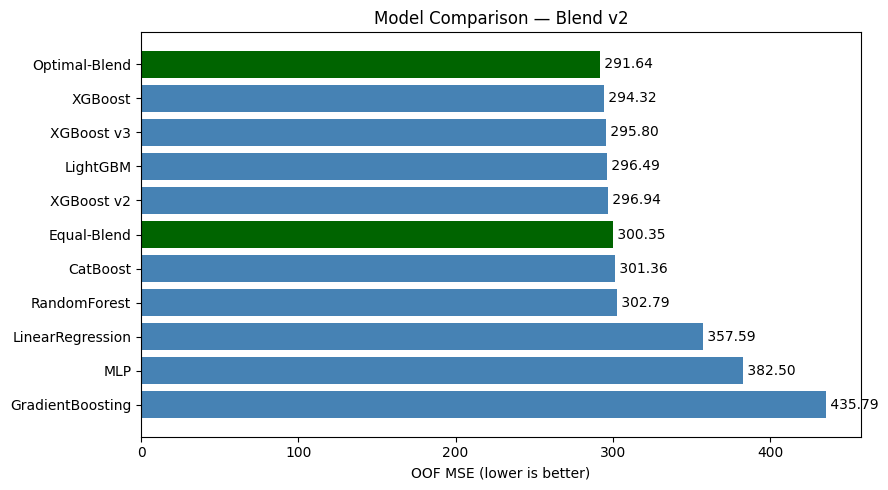

In [6]:
# Full metrics summary + comparison plot
summary_dev = pd.DataFrame(dev_scores).T[['MSE', 'MAE', 'R2']].round(3).sort_values('MSE')
summary_dev.index.name = 'model'
print('=== Dev (5-Fold OOF) metrics ===')
print(summary_dev.to_string())

summary_test = pd.DataFrame(test_scores).T[['MSE', 'MAE', 'R2']].round(3).sort_values('MSE')
summary_test.index.name = 'model'
print('\n=== Local Test metrics ===')
print(summary_test.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['darkgreen' if 'Blend' in n else 'steelblue' for n in summary_dev.index]
ax.barh(summary_dev.index, summary_dev['MSE'].values, color=colors)
for i, v in enumerate(summary_dev['MSE'].values):
    ax.text(v, i, f' {v:.2f}', va='center')
ax.invert_yaxis()
ax.set_xlabel('OOF MSE (lower is better)')
ax.set_title('Model Comparison — Blend v2')
plt.tight_layout(); plt.savefig(OUT_DIR / 'blend_v2_comparison.png', dpi=120); plt.show()